In [ ]:
import os, sys
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import lsstypes as types
import matplotlib.pyplot as plt

sys.path.append('../../')
from fit_tools import LikelihoodBuilder
from helper import REDSHIFT_BIN_LSS
%load_ext autoreload
%autoreload 2
%matplotlib inline

OVERLEAF_DIR = '/global/homes/s/shengyu/Y3/desi_y3_redshift_errors/overleaf/figures'
# save_fig=True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [76]:
tracer = 'QSO'
zrange = REDSHIFT_BIN_LSS[tracer][0]
mock_ids = np.arange(25)

args = dict(
    stats=['mesh2'],
    catalog={
        'version': 'AbacusHF-v2',
        'domain': 'altmtl',
        'tracer': tracer,
        'zrange': zrange,
        'mock_id': 0,
        # 'mock_ids': mock_ids,
        'use_dv': 'verr_nonparam', # False, 'verr_nonparam'
        'z_evol': False,
    },
    covariance={
        'source': 'mock',
        'version': 'holi-v3',
        'mock_ids': range(1000),
        'corrections': ['hartlap', 'percival'],
    },
    cache_dir = './_cache/'
) 

In [77]:
builder = LikelihoodBuilder(**args)

In [78]:
data, window, cov = builder.get_data_stats(unpack=True)

[002605.50]  05-26 01:10  fit_tools                    INFO     Reading data for mesh2 from /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_DR2_v2.0+dv_verr_nonparam.h5
[002605.52]  05-26 01:10  fit_tools                    INFO     Reading window for mesh2 from /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/window_mesh2_spectrum_poles_QSO_z0.8-2.1_DR2_v2.0+dv_verr_nonparam.h5
[002605.58]  05-26 01:10  fit_tools                    INFO     Writing cached stats _cache/prepared_stats/data_QSO1-z0.8-2.1-S2-35fc8d96.h5.
[002605.59]  05-26 01:10  fit_tools                    INFO     Writing cached stats _cache/prepared_stats/window_QSO1-z0.8-2.1-S2-35fc8d96.h5.
[002605.62]  05-26 01:10  fit_tools                    INFO     Reading covariance, first matched: /pscratch/sd/s/shengyu/galaxies/catalogs/Y3/holi-v3/altmtl/QSO/mock0/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_holi_v3+dv_verr_nonparam.h5


[002621.24]  05-26 01:10  fit_tools                    INFO     Built covariance from 844 mock realizations; shape=(112, 112)
[002621.25]  05-26 01:10  fit_tools                    WARNING  Skipped 156 missing covariance mock files
[002621.25]  05-26 01:10  fit_tools                    INFO     Applied covariance corrections ('hartlap', 'percival') with factor 1.306778
[002621.25]  05-26 01:10  fit_tools                    INFO     Writing cached stats _cache/prepared_stats/covariance_QSO1-z0.8-2.1-S2+cov-mock-holi-v3-9945c96f.h5.


In [71]:
builder.get_redshift()

1.4855317513805026

In [28]:
builder.get_likelihood()

[015143.64]  05-21 07:01  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/data_QSO1-z0.8-2.1-S2-8483ac43.h5.
[015143.65]  05-21 07:01  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/window_QSO1-z0.8-2.1-S2-8483ac43.h5.
[015143.68]  05-21 07:01  fit_tools                    INFO     Reading cached stats _cache/prepared_stats/covariance_QSO1-z0.8-2.1-S2+cov-mock-holi-v3-c3e7d2a5.h5.
[015143.70]  05-21 07:01  fit_tools                    WARNING  No redshift found in data attributes; read z=1.486 from the window.
⚠️ No GPU found. Using JAX with CPU.
Calculating matrices (no save path specified)


/global/homes/s/shengyu/.conda/envs/fit_env/lib/python3.12/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuNoWiggleEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


Calculating matrices (no save path specified)
[015154.44]  05-21 07:01  fit_tools                    INFO     Fitting emulator _cache/emulator_cosmo-base_ns-fixed_taylor/emulator_QSO1-z0.8-2.1-S2-th-folpsD_7a961098.npy
Calculating matrices (no save path specified)
[015160.68]  05-21 07:01  Emulator                     INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[015160.68]  05-21 07:01  Emulator                     INFO     Found varying ['H0', 'Omega_m', 'sigma8_m', 'sigma8', 'fsigma8', 'pt-jac', 'pt-kap', 'pt-muap', 'pt-table', 'pt-table_now', 'pt-scalars', 'pt-scalars_now', 'pt-qpar', 'pt-qper', 'pt-f', 'pt-f0', 'pt-pklir'] and fixed ['k', 'z', 'ells', 'wmu', 'kt', 'pt-A_full', 'pt-remove_DeltaP'] outputs.
[015161.46]  05-21 07:01  Differentiation              INFO     Varied parameters: ['h', 'omega_cdm', 'omega_b', 'logA'].
[015164.66]  05-21 07:02  Differentiation              INFO     h grid is [0.6136 0.6436 0.6736 0.7036 0.7336].
[015164.66]  05-21 07:02

## corss-check with the direct read

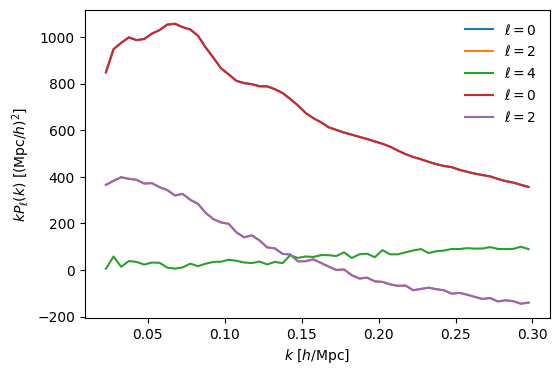

In [65]:
data2 = []
for mock_id in mock_ids:
    fn = f'/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock{mock_id}/mpspk/mesh2_spectrum_poles_QSO_z0.8-2.1_DR2_v2.0.h5'
    d = types.read(fn)
    sl = slice(0, None, 5)  # rebin to dk = 0.005 h/Mpc
    oklim = (0.02, 0.3)  # fitted k-range, no need to go to higher k
    d = d.select(k=sl).select(k=oklim)
    data2.append(d)

data2= types.mean(data2)
fig = plt.figure(figsize=(6, 4))
data2.plot(fig=fig)
data[0].plot(fig=fig)
plt.show()